In [11]:
from google.colab import drive
drive.mount('/content/drive')
# Now you can access your file at:
# '/content/drive/My Drive/Mining_process_database_Practica/MiningProcess_Flotation_Plant_Database.csv'
# 1. Ruta y carga del dataset completo
ruta = '/content/drive/My Drive/Mining_process_database_Practica/MiningProcess_Flotation_Plant_Database.csv'
df_completo = pd.read_csv(ruta, decimal=",")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd

In [15]:
# 2. Procesamiento de fechas y creación de la columna 'Turno'
df_completo['date'] = pd.to_datetime(df_completo['date'])
df_completo['Turno'] = df_completo['date'].dt.hour.apply(
    lambda x: 'Turno Día' if 6 <= x < 18 else 'Turno Noche'
)
# 3. Limpieza inicial: Eliminar duplicados del sistema de adquisición
df_completo = df_completo.drop_duplicates().reset_index(drop=True)

# 4. Creación de la columna categórica 'Calidad_Silica'
col_silica = '% Silica Concentrate'
df_completo['Calidad_Silica'] = df_completo[col_silica].apply(
    lambda x: 'Alta Pureza' if x < 3.0 else 'Baja Pureza'
)

# 5. Muestreo estratificado (50.000 muestras por turno para garantizar equilibrio)
df = df_completo.groupby('Turno').sample(n=50000, random_state=42).reset_index(drop=True)

# 6. Verificación del balanceo de turnos
print(f"Tamaño del nuevo dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
print("Distribución de lecturas por turno:")
print(df['Turno'].value_counts())
print("\n" + "="*60 + "\n")

# 7. Tabla de rendimiento cruzada: Turno vs Calidad
print("TABLA DE CONCENTRACIONES MEDIAS SEGÚN TURNO Y CALIDAD:")
columnas_concentracion = ['% Iron Concentrate', '% Silica Concentrate']
tabla_resumen = df.groupby(['Turno', 'Calidad_Silica'])[columnas_concentracion].mean()
display(tabla_resumen)

Tamaño del nuevo dataset: 100000 filas y 26 columnas.

Distribución de lecturas por turno:
Turno
Turno Día      50000
Turno Noche    50000
Name: count, dtype: int64


TABLA DE CONCENTRACIONES MEDIAS SEGÚN TURNO Y CALIDAD:


% Iron Concentrate  % Silica Concentrate
Turno       Calidad_Silica                                          
Turno Día   Alta Pureza              65.494300              1.797210
            Baja Pureza              63.704916              3.980211
Turno Noche Alta Pureza              65.510997              1.730653
            Baja Pureza              63.706172              4.022709

In [16]:
# 8. Verificación final de calidad
print("=== VERIFICACIÓN FINAL ===")
print(f"Tamaño del dataset final: {df.shape[0]} filas.")
print(f"Nulos: {df.isnull().sum().sum()} | Duplicados: {df.duplicated().sum()}")
print("\n=== RENDIMIENTO POR TURNO Y CALIDAD ===")
columnas_concentracion = ['% Iron Concentrate', '% Silica Concentrate']
tabla_resumen = df.groupby(['Turno', 'Calidad_Silica'])[columnas_concentracion].mean()
display(tabla_resumen)

=== VERIFICACIÓN FINAL ===
Tamaño del dataset final: 100000 filas.
Nulos: 0 | Duplicados: 0

=== RENDIMIENTO POR TURNO Y CALIDAD ===


% Iron Concentrate  % Silica Concentrate
Turno       Calidad_Silica                                          
Turno Día   Alta Pureza              65.494300              1.797210
            Baja Pureza              63.704916              3.980211
Turno Noche Alta Pureza              65.510997              1.730653
            Baja Pureza              63.706172              4.022709

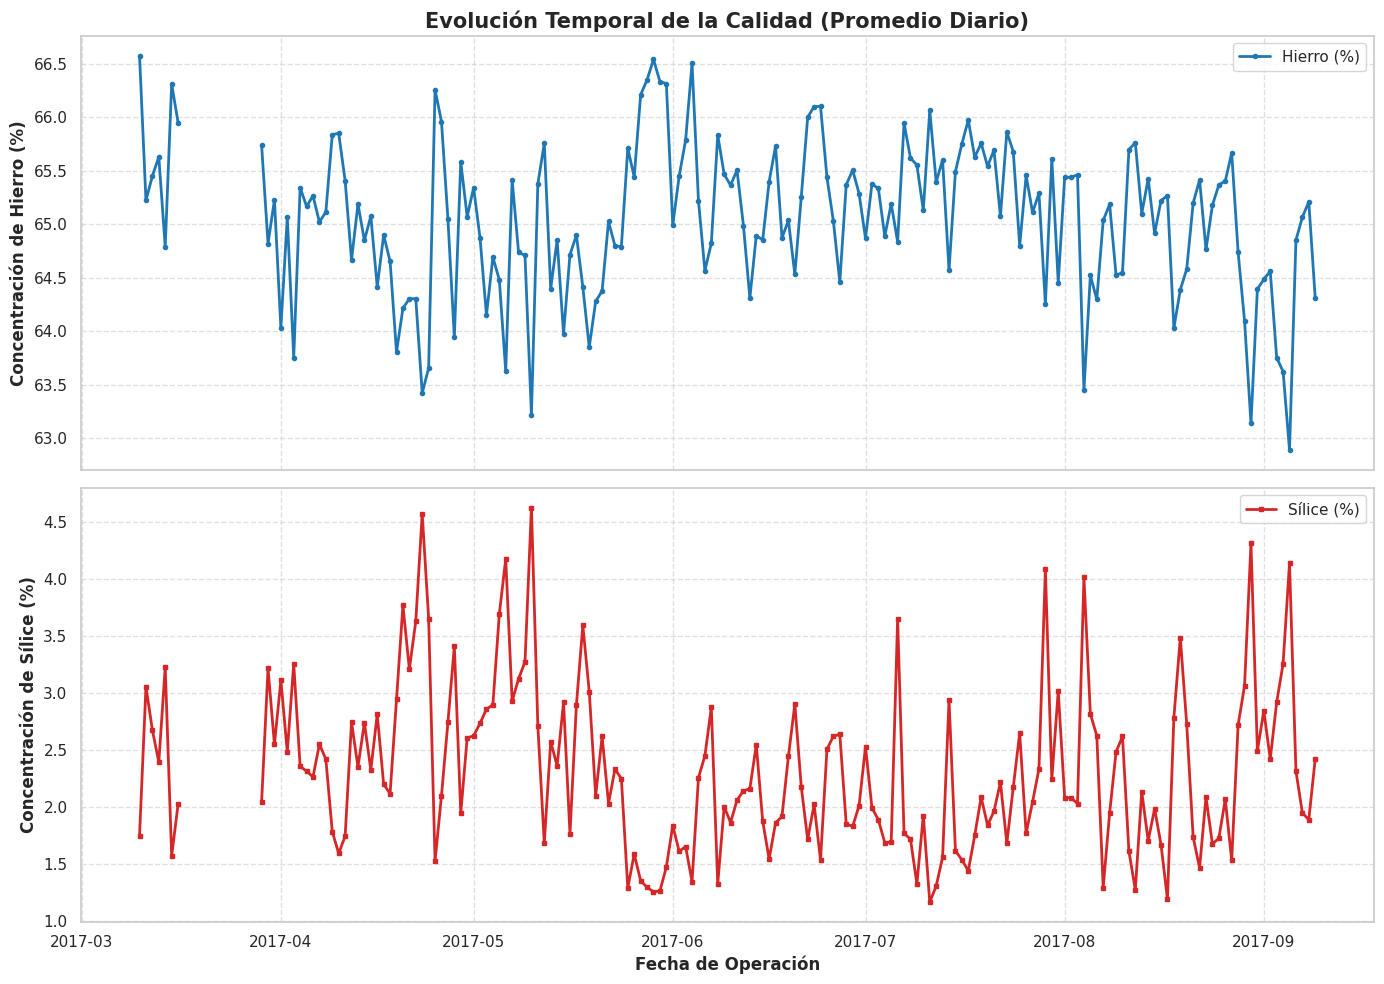

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración inicial
sns.set_theme(style="whitegrid")

# Creamos una figura con 2 filas (nrows=2) y 1 columna (ncols=1)
# sharex=True hace que ambos gráficos compartan la misma línea de tiempo en el eje X
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# ==========================================
# GRÁFICO SUPERIOR: CONCENTRACIÓN DE HIERRO
# ==========================================
color_hierro = '#1f77b4'
ax1.plot(df_tendencia.index, df_tendencia['% Iron Concentrate'],
         label='Hierro (%)', color=color_hierro, linewidth=2, marker='o', markersize=3)
ax1.set_title('Evolución Temporal de la Calidad (Promedio Diario)', fontsize=15, fontweight='bold')
ax1.set_ylabel('Concentración de Hierro (%)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# ==========================================
# GRÁFICO INFERIOR: CONCENTRACIÓN DE SÍLICE
# ==========================================
color_silice = '#d62728'
ax2.plot(df_tendencia.index, df_tendencia['% Silica Concentrate'],
         label='Sílice (%)', color=color_silice, linewidth=2, marker='s', markersize=3)
ax2.set_xlabel('Fecha de Operación', fontsize=12, fontweight='bold')
ax2.set_ylabel('Concentración de Sílice (%)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

# Ajustamos el espaciado para que no se superpongan los textos
fig.tight_layout()

# Mostrar gráficos
plt.show()

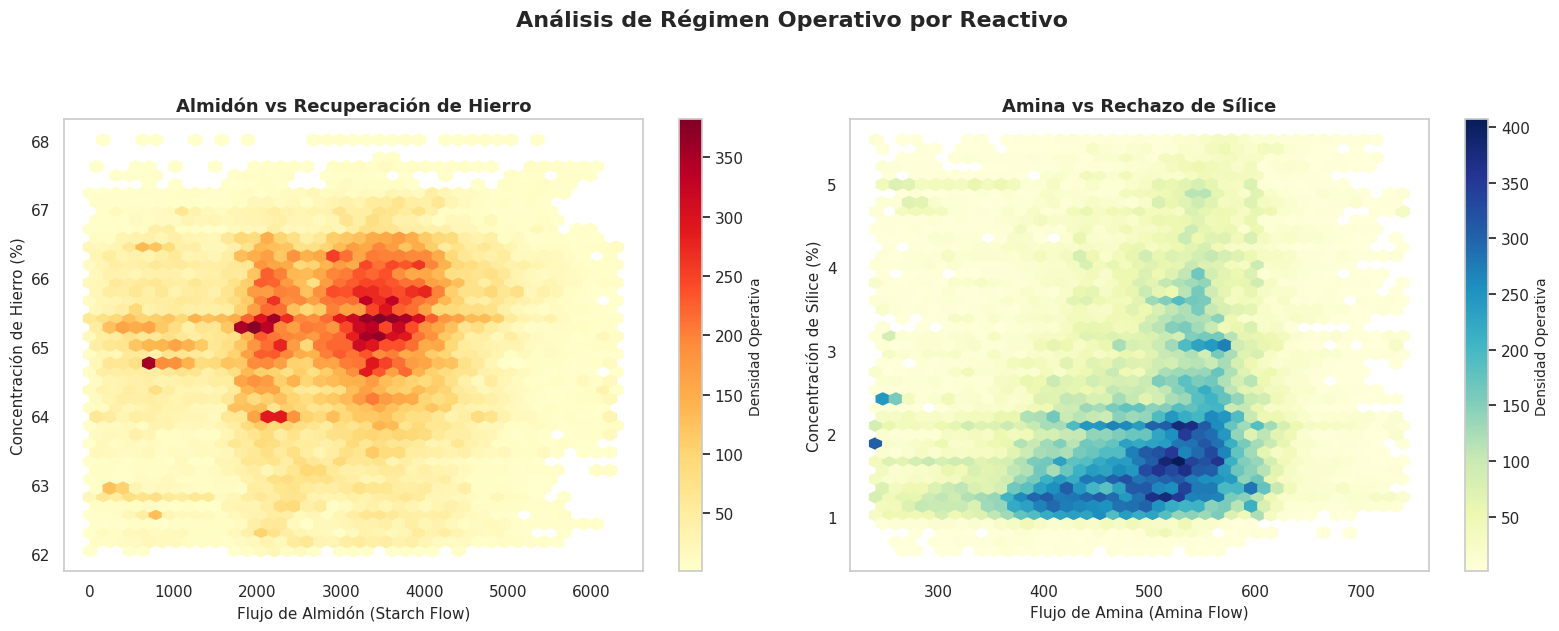

In [30]:
# Creamos la figura con 1 fila y 2 columnas. Ajustamos el ancho (16) para que entren bien
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# ==========================================
# GRÁFICO 1 (IZQUIERDA): Almidón vs Hierro
# ==========================================
hb1 = ax1.hexbin(
    x=df['Starch Flow'],
    y=df['% Iron Concentrate'],
    gridsize=40,
    cmap='YlOrRd',
    mincnt=1
)
# Barra de color específica para el gráfico 1
cb1 = fig.colorbar(hb1, ax=ax1)
cb1.set_label('Densidad Operativa', fontsize=10)

ax1.set_title('Almidón vs Recuperación de Hierro', fontsize=13, fontweight='bold')
ax1.set_xlabel('Flujo de Almidón (Starch Flow)', fontsize=11)
ax1.set_ylabel('Concentración de Hierro (%)', fontsize=11)
ax1.grid(False)

# ==========================================
# GRÁFICO 2 (DERECHA): Amina vs Sílice
# ==========================================
hb2 = ax2.hexbin(
    x=df['Amina Flow'],
    y=df['% Silica Concentrate'],
    gridsize=40,
    cmap='YlGnBu',  # Tonos azules/verdes para diferenciar el reactivo
    mincnt=1
)
# Barra de color específica para el gráfico 2
cb2 = fig.colorbar(hb2, ax=ax2)
cb2.set_label('Densidad Operativa', fontsize=10)

ax2.set_title('Amina vs Rechazo de Sílice', fontsize=13, fontweight='bold')
ax2.set_xlabel('Flujo de Amina (Amina Flow)', fontsize=11)
ax2.set_ylabel('Concentración de Sílice (%)', fontsize=11)
ax2.grid(False)

# ==========================================
# AJUSTES FINALES
# ==========================================
# Título general para todo el panel
fig.suptitle('Análisis de Régimen Operativo por Reactivo', fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

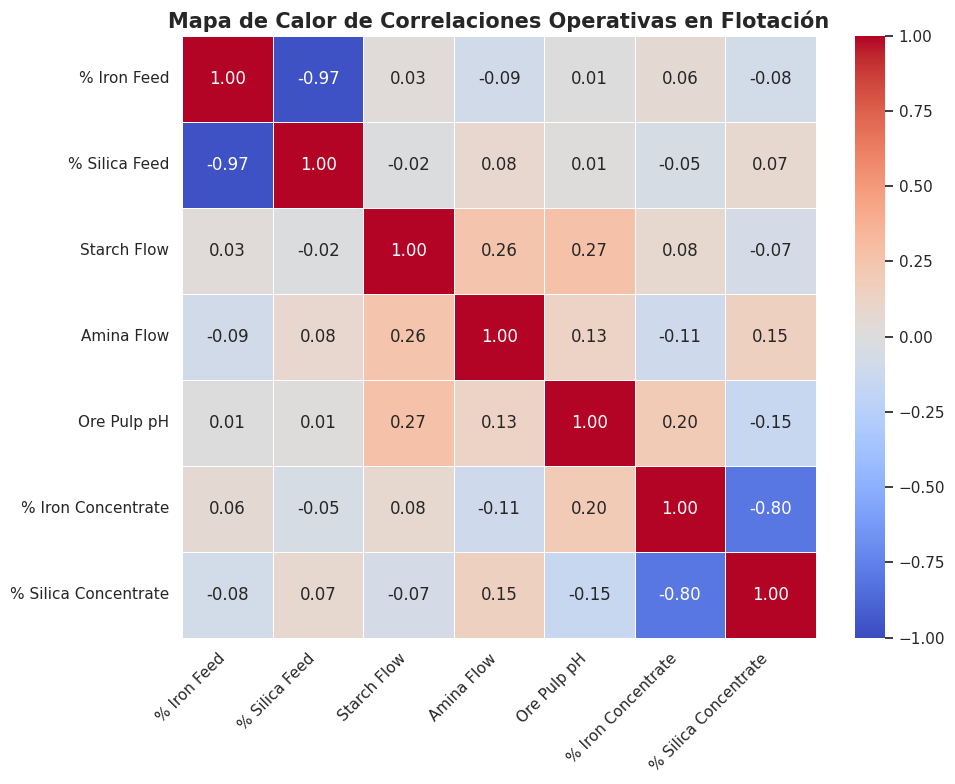

In [28]:
# 1. Seleccionamos solo las variables operativas críticas para no saturar el gráfico
columnas_clave = [
    '% Iron Feed',           # Lo que entra de la mina (Hierro)
    '% Silica Feed',         # Lo que entra de la mina (Sílice)
    'Starch Flow',           # Reactivo 1 (Almidón)
    'Amina Flow',            # Reactivo 2 (Amina)
    'Ore Pulp pH',           # pH de la pulpa
    '% Iron Concentrate',    # Resultado final (Hierro)
    '% Silica Concentrate'   # Resultado final (Sílice)
]

# 2. Calculamos la matriz de correlación (método de Pearson por defecto)
matriz_corr = df[columnas_clave].corr()

# 3. Configuración visual del Mapa de Calor
plt.figure(figsize=(10, 8))

# sns.heatmap dibuja la matriz.
# annot=True pone los números, cmap='coolwarm' le da el color azul-rojo
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",           # Muestra 2 decimales
    linewidths=0.5,
    vmin=-1, vmax=1      # La escala siempre va de -1 a 1
)

plt.title('Mapa de Calor de Correlaciones Operativas en Flotación', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

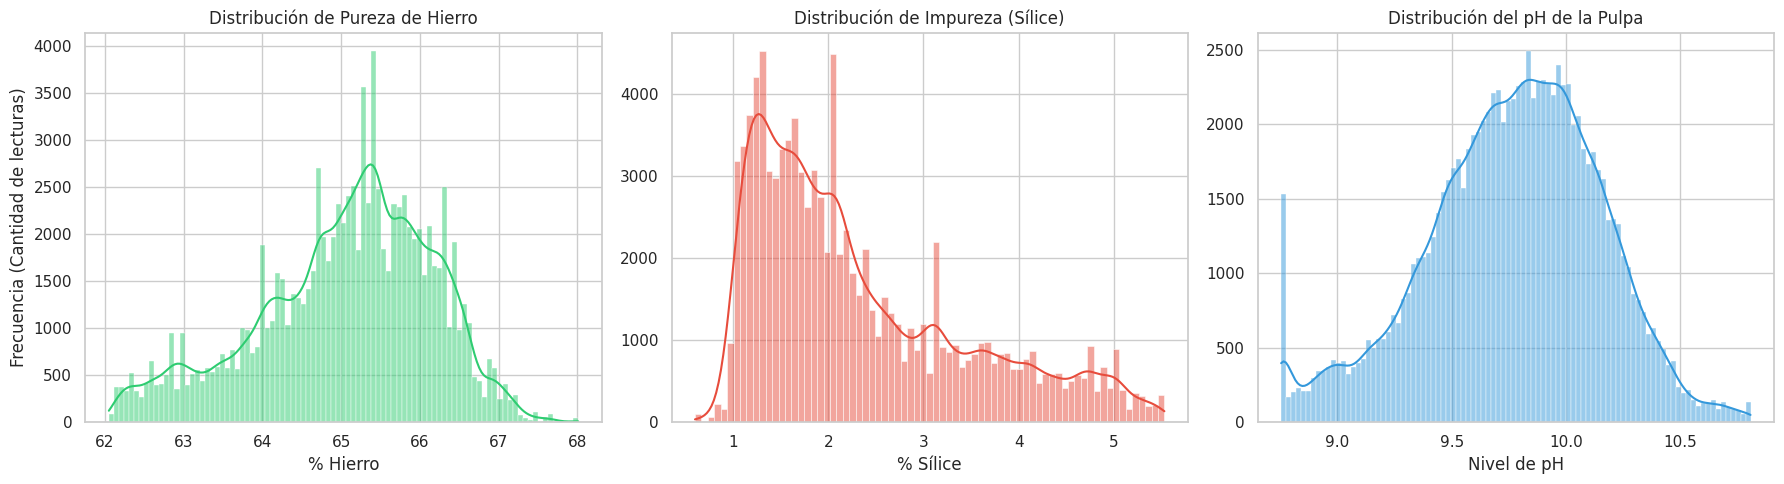

In [26]:
# Herramientas de dibujo
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo
sns.set_theme(style="whitegrid")

# Canva
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- GRÁFICO 1: Pureza del Hierro ---
# ax=axes[0] significa que va en el primer lugar de la izquierda
sns.histplot(data=df, x='% Iron Concentrate', kde=True, color='#2ecc71', ax=axes[0])
axes[0].set_title('Distribución de Pureza de Hierro')
axes[0].set_xlabel('% Hierro')
axes[0].set_ylabel('Frecuencia (Cantidad de lecturas)')

# --- GRÁFICO 2: Impureza (Sílice) ---
# ax=axes[1] va en el medio
sns.histplot(data=df, x='% Silica Concentrate', kde=True, color='#e74c3c', ax=axes[1])
axes[1].set_title('Distribución de Impureza (Sílice)')
axes[1].set_xlabel('% Sílice')
axes[1].set_ylabel('') # Borramos el texto del eje Y para no repetir

# --- GRÁFICO 3: pH de la Pulpa ---
# ax=axes[2] va a la derecha
sns.histplot(data=df, x='Ore Pulp pH', kde=True, color='#3498db', ax=axes[2])
axes[2].set_title('Distribución del pH de la Pulpa')
axes[2].set_xlabel('Nivel de pH')
axes[2].set_ylabel('')

# Ajustamos los márgenes para que no se superpongan y mostramos el resultado
plt.tight_layout()
plt.show()

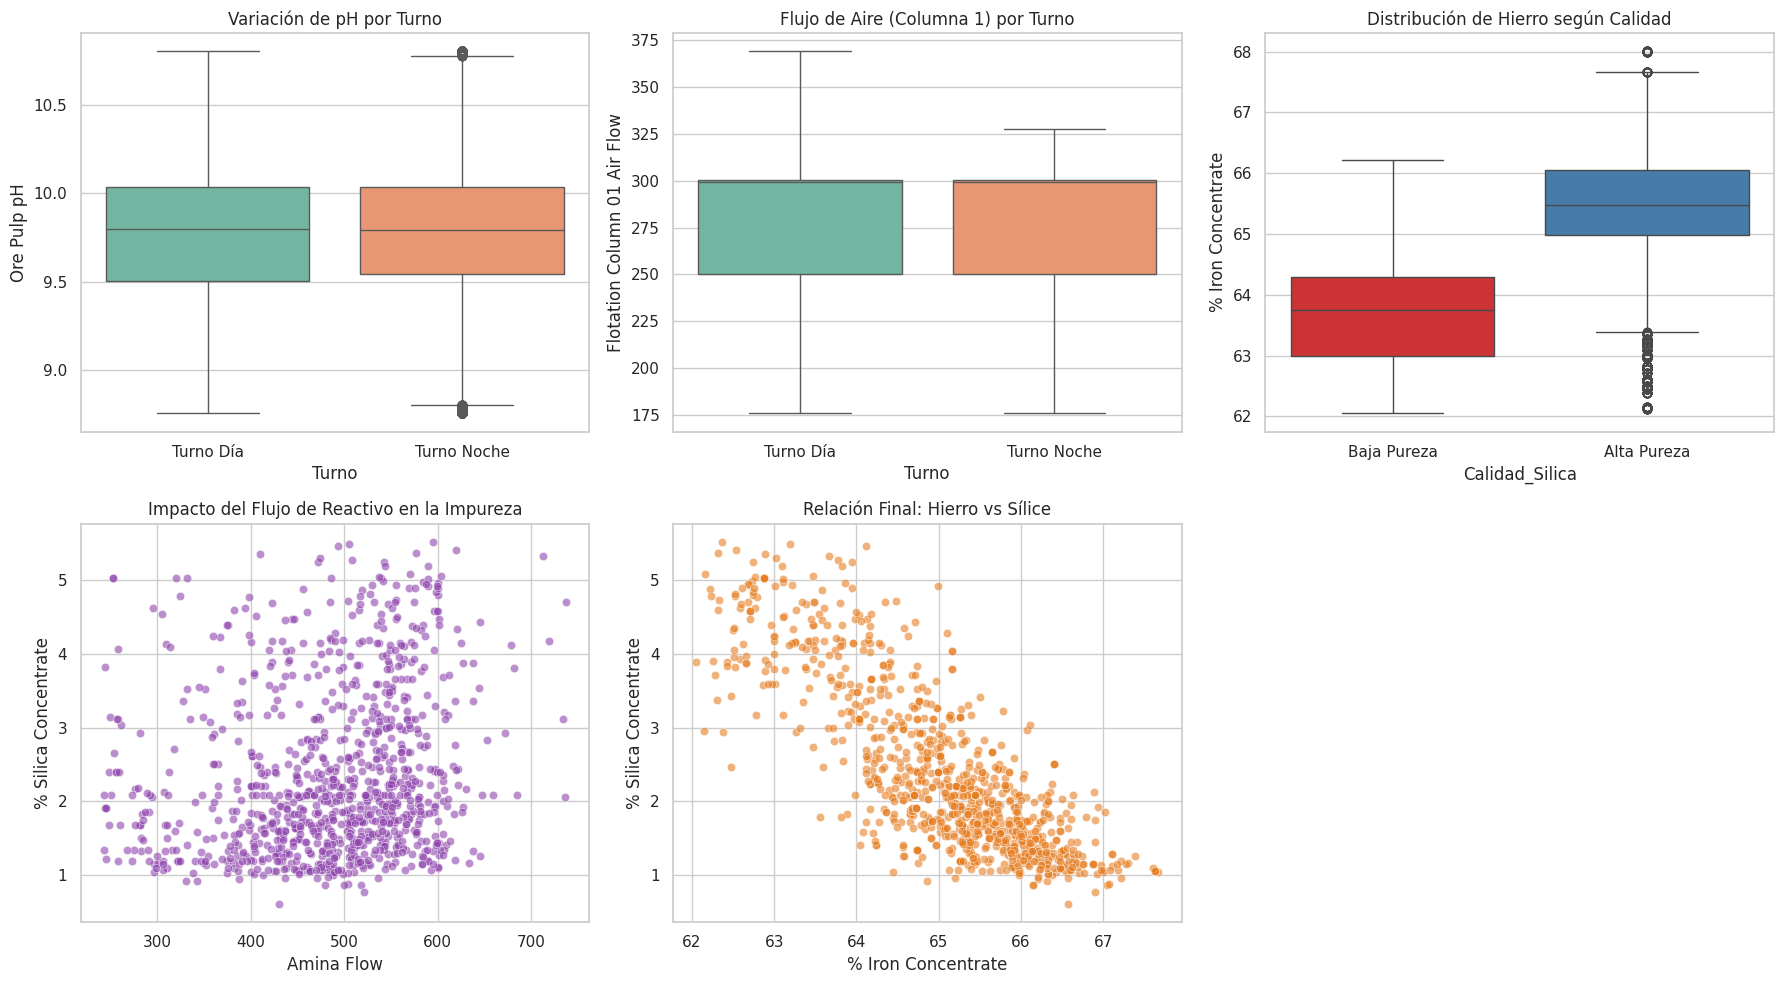

In [25]:
# --- Horarios, boxplots y scatterplots ---
def asignar_turno_real(hora):
    if 7 <= hora < 19:
        return 'Turno Día'
    else:
        return 'Turno Noche'

# Aplicamos la función para sobreescribir la memoria de Colab
df['Turno'] = df['date'].dt.hour.apply(asignar_turno_real)

# --- 2. DIBUJAMOS LOS GRÁFICOS ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
orden_turnos = ['Turno Día', 'Turno Noche']

# 1. pH de la pulpa vs Turno
sns.boxplot(data=df, x='Turno', y='Ore Pulp pH', ax=axes[0,0], order=orden_turnos, hue='Turno', palette='Set2')
axes[0,0].set_title('Variación de pH por Turno')

# 2. Flujo de Aire vs Turno
sns.boxplot(data=df, x='Turno', y='Flotation Column 01 Air Flow', ax=axes[0,1], order=orden_turnos, hue='Turno', palette='Set2')
axes[0,1].set_title('Flujo de Aire (Columna 1) por Turno')

# 3. Pureza de Hierro vs Categoría de Calidad
sns.boxplot(data=df, x='Calidad_Silica', y='% Iron Concentrate', ax=axes[0,2], hue='Calidad_Silica', palette='Set1')
axes[0,2].set_title('Distribución de Hierro según Calidad')

# --- SCATTERPLOTS ---
df_sample = df.sample(1000, random_state=42)

# 4. Reactivo (Amina) vs Impureza (Sílice)
sns.scatterplot(data=df_sample, x='Amina Flow', y='% Silica Concentrate', alpha=0.6, color='#8e44ad', ax=axes[1,0])
axes[1,0].set_title('Impacto del Flujo de Reactivo en la Impureza')

# 5. Concentrado de Hierro vs Concentrado de Sílice
sns.scatterplot(data=df_sample, x='% Iron Concentrate', y='% Silica Concentrate', alpha=0.6, color='#e67e22', ax=axes[1,1])
axes[1,1].set_title('Relación Final: Hierro vs Sílice')

fig.delaxes(axes[1,2])
plt.tight_layout()
plt.show()

/tmp/ipykernel_3812/996459664.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Turno', order=['Turno Día', 'Turno Noche'], palette='viridis', ax=axes[1])
/tmp/ipykernel_3812/996459664.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Turno', y='% Iron Concentrate', order=['Turno Día', 'Turno Noche'],


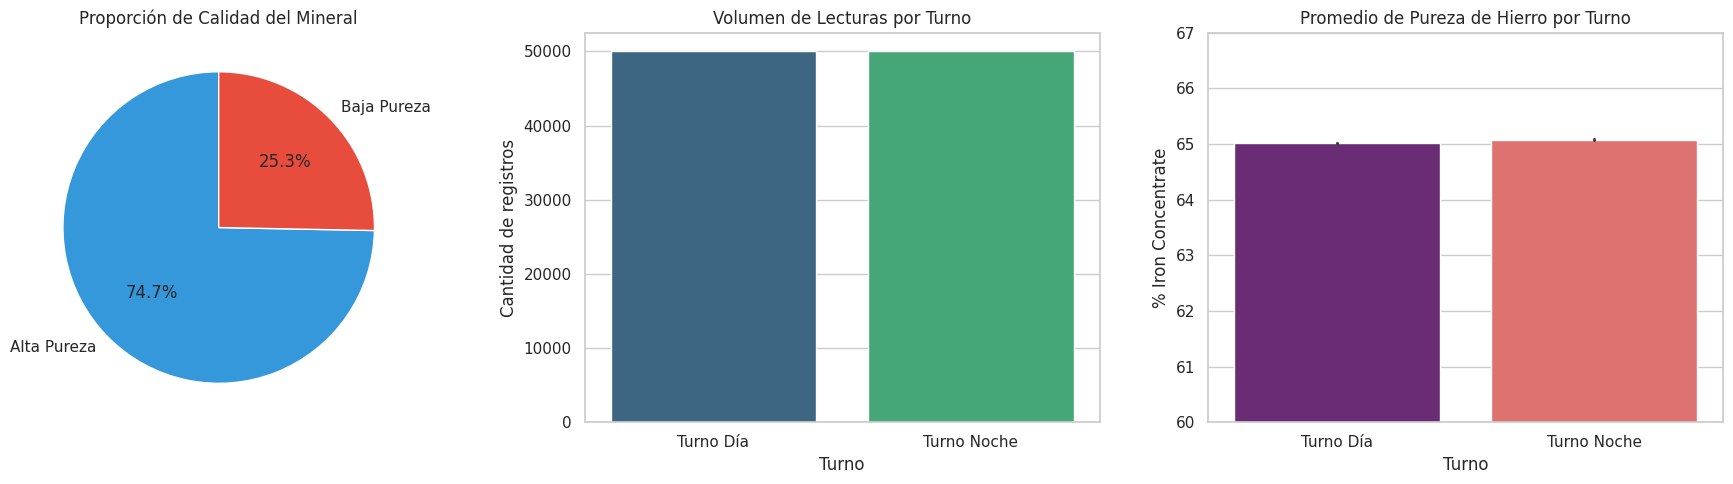

In [24]:
# --- 3. DIBUJAMOS LOS GRÁFICOS DE BARRAS Y TORTA ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Torta: Proporción de Calidad
calidad_counts = df['Calidad_Silica'].value_counts()
axes[0].pie(calidad_counts, labels=calidad_counts.index, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Proporción de Calidad del Mineral')

# 2. Barras: Cantidad de lecturas
sns.countplot(data=df, x='Turno', order=['Turno Día', 'Turno Noche'], palette='viridis', ax=axes[1])
axes[1].set_title('Volumen de Lecturas por Turno')
axes[1].set_ylabel('Cantidad de registros')

# 3. Barras: Promedio de pureza
sns.barplot(data=df, x='Turno', y='% Iron Concentrate', order=['Turno Día', 'Turno Noche'],
            palette='magma', ax=axes[2])
axes[2].set_title('Promedio de Pureza de Hierro por Turno')
axes[2].set_ylim(60, 67)

plt.tight_layout()
plt.show()